# Script to view the changes in species concentration and radiative forcing from rocket launches and object re-entries.

In [34]:
# Import modules
import sys, os
#sys.path.append('/home/ucfacb0/rundirs/Rockets/gc_4x5_47L_merra2_fullchem_main/OutputDir')
import numpy as np
import netCDF4
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as colors
import cartopy.crs as ccrs
from gamap_colormap import WhGrYlRd
from ipywidgets import interact, IntSlider, SelectionSlider, Dropdown

# Set up arrays
months =['01','02','03','04','05','06','07','08','09','10','11','12']
years = ["2020","2021","2022"]
filepath     = '/home/ucfacb0/rundirs/Rockets/gc_4x5_47L_merra2_fullchem_main/OutputDir/'
rocketsSim   ='Rockets' 
norocketsSim = 'Baseline'
Plower =200
Pupper = 1
species = ["BC","NOx","O3"]#,"Al2O3","Cly","CO","DST"]

### Retrieve concentrations from SpeciesConc over the stratosphere.

In [35]:
mon_mean_nr, mon_mean_wr = np.zeros((len(species),len(months)*len(years))), np.zeros((len(species),len(months)*len(years)))
year_labels = [2020]
count = 0
for year_count,year in enumerate(years):
    for mth in months:
        print(mth)
        year_labels.append(int(mth)/12+year_count+2020)
        if year == "2022" and int(mth) > 7:
            #pass
            continue
        met = xr.open_dataset(f'/home/ucfacb0/Scratch/StateMet/4x5/{year}/GEOSChem.StateMet.{year}{mth}01_0000z.nc4')
        try:
            wr  = xr.open_dataset(filepath+rocketsSim+f'/GEOSChem.SpeciesConc.{year}{mth}01_0000z.nc4') 
        except:
            wr  = xr.open_dataset(filepath+rocketsSim+f'/before_atlas_fix/GEOSChem.SpeciesConc.{year}{mth}01_0000z.nc4') 
        nr  = xr.open_dataset(filepath+norocketsSim+f'/GEOSChem.SpeciesConc.{year}{mth}01_0000z.nc4' )
        
        # Set up the pressure ranges.
        time, lon, lat = nr.variables['time'][:], nr.variables['lon'][:], nr.variables['lat'][:]
        P0, hyai, hybi = nr.variables['P0'], nr.variables['hyai'][:], nr.variables['hybi'][:]
        Pedge = [ hyai[i] + (hybi[i]*1000) for i in np.arange(len(hyai)) ]
        iu = np.argmin(np.abs([ Pedge[i] - Pupper for i in np.arange(len(Pedge)) ] )) # grid index of upper pressure level
        il = np.argmin(np.abs([ Pedge[i] - Plower for i in np.arange(len(Pedge)) ] )) # grid index of lower pressure level   
        Pedge = Pedge[il:iu]
        
        # Black carbon
        mon_mean_nr[0,count] = (nr["SpeciesConcVV_BCPO"].isel(time=0,lev=(np.arange(il,iu))).mean().values + 
                                nr["SpeciesConcVV_BCPI"].isel(time=0,lev=(np.arange(il,iu))).mean().values) * 1e12
        mon_mean_wr[0,count] = (wr["SpeciesConcVV_BCPO"].isel(time=0,lev=(np.arange(il,iu))).mean().values + 
                                wr["SpeciesConcVV_BCPI"].isel(time=0,lev=(np.arange(il,iu))).mean().values) * 1e12          
        
        # NOx
        mon_mean_nr[1,count] = (nr["SpeciesConcVV_NO"].isel(time=0,lev=(np.arange(il,iu))).mean().values + 
                                nr["SpeciesConcVV_NO2"].isel(time=0,lev=(np.arange(il,iu))).mean().values) * 1e12
        mon_mean_wr[1,count] = (wr["SpeciesConcVV_NO"].isel(time=0,lev=(np.arange(il,iu))).mean().values + 
                                wr["SpeciesConcVV_NO2"].isel(time=0,lev=(np.arange(il,iu))).mean().values) * 1e12  
        
        # Ozone
        mon_mean_nr[2,count] =  nr["SpeciesConcVV_O3"].isel(time=0,lev=(np.arange(il,iu))).mean().values * 1e12
        mon_mean_wr[2,count] =  wr["SpeciesConcVV_O3"].isel(time=0,lev=(np.arange(il,iu))).mean().values * 1e12 
        
        # Alumina
        #mon_mean_wr[3,count] =  wr["SpeciesConcVV_AL2O3"].isel(time=0,lev=(np.arange(il,iu))).mean().values * 1e12 
        #
        ## Chlorine
        #mon_mean_nr[4,count] = (nr["SpeciesConcVV_Cl"].isel(time=0,lev=(np.arange(il,iu))).mean().values + 
        #                        nr["SpeciesConcVV_Cl2"].isel(time=0,lev=(np.arange(il,iu))).mean().values * 2 +
        #                        nr["SpeciesConcVV_ClNO3"].isel(time=0,lev=(np.arange(il,iu))).mean().values +
        #                        nr["SpeciesConcVV_Cl2O2"].isel(time=0,lev=(np.arange(il,iu))).mean().values * 2 +
        #                        nr["SpeciesConcVV_ClO"].isel(time=0,lev=(np.arange(il,iu))).mean().values +
        #                        nr["SpeciesConcVV_ClNO2"].isel(time=0,lev=(np.arange(il,iu))).mean().values +
        #                        nr["SpeciesConcVV_ClOO"].isel(time=0,lev=(np.arange(il,iu))).mean().values +
        #                        nr["SpeciesConcVV_HCl"].isel(time=0,lev=(np.arange(il,iu))).mean().values +
        #                        nr["SpeciesConcVV_OClO"].isel(time=0,lev=(np.arange(il,iu))).mean().values +
        #                        nr["SpeciesConcVV_BrCl"].isel(time=0,lev=(np.arange(il,iu))).mean().values +
        #                        nr["SpeciesConcVV_HOCl"].isel(time=0,lev=(np.arange(il,iu))).mean().values +
        #                        nr["SpeciesConcVV_ICl"].isel(time=0,lev=(np.arange(il,iu))).mean().values) * 1e12
        #
        #mon_mean_wr[4,count] = (wr["SpeciesConcVV_Cl"].isel(time=0,lev=(np.arange(il,iu))).mean().values + 
        #                        wr["SpeciesConcVV_Cl2"].isel(time=0,lev=(np.arange(il,iu))).mean().values * 2 +
        #                        wr["SpeciesConcVV_ClNO3"].isel(time=0,lev=(np.arange(il,iu))).mean().values +
        #                        wr["SpeciesConcVV_Cl2O2"].isel(time=0,lev=(np.arange(il,iu))).mean().values * 2 +
        #                        wr["SpeciesConcVV_ClO"].isel(time=0,lev=(np.arange(il,iu))).mean().values +
        #                        wr["SpeciesConcVV_ClNO2"].isel(time=0,lev=(np.arange(il,iu))).mean().values +
        #                        wr["SpeciesConcVV_ClOO"].isel(time=0,lev=(np.arange(il,iu))).mean().values +
        #                        wr["SpeciesConcVV_HCl"].isel(time=0,lev=(np.arange(il,iu))).mean().values +
        #                        wr["SpeciesConcVV_OClO"].isel(time=0,lev=(np.arange(il,iu))).mean().values +
        #                        wr["SpeciesConcVV_BrCl"].isel(time=0,lev=(np.arange(il,iu))).mean().values +
        #                        wr["SpeciesConcVV_HOCl"].isel(time=0,lev=(np.arange(il,iu))).mean().values +
        #                        wr["SpeciesConcVV_ICl"].isel(time=0,lev=(np.arange(il,iu))).mean().values) * 1e12
        
        # Carbon Monoxide
        #mon_mean_nr[5,count] =  nr["SpeciesConcVV_CO"].isel(time=0,lev=(np.arange(il,iu))).mean().values * 1e12
        #mon_mean_wr[5,count] =  wr["SpeciesConcVV_CO"].isel(time=0,lev=(np.arange(il,iu))).mean().values * 1e12
        
        # Dust
        #mon_mean_nr[6,count] =  (nr["SpeciesConcVV_DST1"].isel(time=0,lev=(np.arange(il,iu))).mean().values +
        #                         nr["SpeciesConcVV_DST2"].isel(time=0,lev=(np.arange(il,iu))).mean().values +
        #                         nr["SpeciesConcVV_DST3"].isel(time=0,lev=(np.arange(il,iu))).mean().values +
        #                         nr["SpeciesConcVV_DST4"].isel(time=0,lev=(np.arange(il,iu))).mean().values) * 1e12
        #mon_mean_wr[6,count] =  (wr["SpeciesConcVV_DST1"].isel(time=0,lev=(np.arange(il,iu))).mean().values +
        #                         wr["SpeciesConcVV_DST2"].isel(time=0,lev=(np.arange(il,iu))).mean().values +
        #                         wr["SpeciesConcVV_DST3"].isel(time=0,lev=(np.arange(il,iu))).mean().values +
        #                         wr["SpeciesConcVV_DST4"].isel(time=0,lev=(np.arange(il,iu))).mean().values) * 1e12
                    
        # Keep the counter going and build the x axis label array.
        count += 1
        
        wr.close()
        nr.close()

print(year_labels)


01
02
03
04
05
06
07
08
09
10
11
12
01
02
03
04
05
06
07
08
09
10
11
12
01
02
03
04
05
06
07
08
09
10
11
12
[2020, 2020.0833333333333, 2020.1666666666667, 2020.25, 2020.3333333333333, 2020.4166666666667, 2020.5, 2020.5833333333333, 2020.6666666666667, 2020.75, 2020.8333333333333, 2020.9166666666667, 2021.0, 2021.0833333333333, 2021.1666666666667, 2021.25, 2021.3333333333333, 2021.4166666666667, 2021.5, 2021.5833333333333, 2021.6666666666667, 2021.75, 2021.8333333333333, 2021.9166666666667, 2022.0, 2022.0833333333333, 2022.1666666666667, 2022.25, 2022.3333333333333, 2022.4166666666667, 2022.5, 2022.5833333333333, 2022.6666666666667, 2022.75, 2022.8333333333333, 2022.9166666666667, 2023.0]


### Output the SpeciesConc Plots

120.12856390147407
0.04080334511990196
-0.007334374115945976


/tmp/ipykernel_10059/3158492779.py:3: RuntimeWarning: invalid value encountered in divide
  mon_mean_per  = mon_mean_diff / mon_mean_nr[spec_count,:] * 100


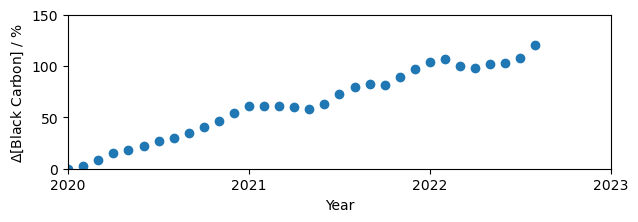

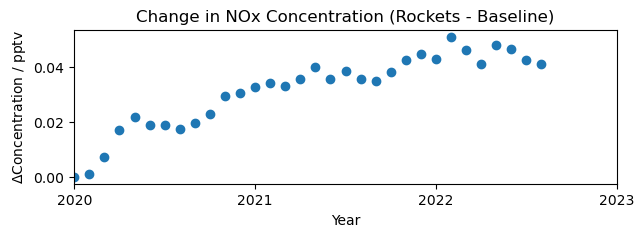

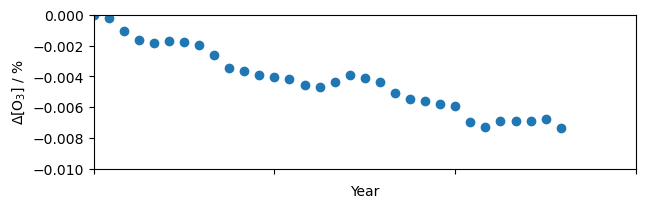

In [36]:
for spec_count in range(len(species)):
    mon_mean_diff = mon_mean_wr[spec_count,:]-mon_mean_nr[spec_count,:]
    mon_mean_per  = mon_mean_diff / mon_mean_nr[spec_count,:] * 100
    y_plot = np.insert(mon_mean_per,0,0)
    fig, ax = plt.subplots(figsize=(7,2))
    ax.scatter(year_labels[:32],y_plot[:32])
    print(y_plot[31])
    ax.set_xlabel("Year")
    ax.set_ylabel("$\Delta$Concentration / pptv")
    ax.set_xticks(np.linspace(2020,2023,4))
    ax.set_xlim(2020,2023)
    ax.set_title(f"Change in {species[spec_count]} Concentration (Rockets - Baseline)")
    if spec_count == 0:
        ax.set_ylim(0,150)
        ax.set_title("")
        ax.set_ylabel("$\Delta$[Black Carbon] / %")
        #ax.set_xticklabels("")
    elif spec_count == 2:
        ax.set_ylim(-0.010,0)
        ax.set_title("")
        ax.set_ylabel("$\Delta$[O$_{3}$] / %")
        ax.set_xticklabels("")
    #elif spec_count in [0,1]:
    #    ax.set_ylim(0,6)
    #elif spec_count == 3:
    #    ax.set_ylim(0,0.15) 
    #elif spec_count == 4: 
    #    ax.set_ylim(0,1.8)  
    #elif spec_count == 5: 
    #    ax.set_ylim(0,6)          
    elif spec_count == 6: 
        ax.set_ylim(0,30)
        ax.set_title("")
        ax.set_ylabel("$\Delta$[Mineral Dust] / %")

#mon_mean_diff_al = mon_mean_wr[3,:]-mon_mean_nr[3,:]
#mon_mean_diff_du = mon_mean_wr[6,:]-mon_mean_nr[6,:]
#fig, ax = plt.subplots(figsize=(7,2))
#ax.scatter(year_labels,np.insert(mon_mean_diff_du/mon_mean_diff_al,0,0))
#ax.set_xlabel("Year")
#ax.set_ylabel("DST1-4/Al2O3 ratio / unitless")
#ax.set_xticks(np.linspace(2020,2030,11))
#ax.set_title(f"Ratio between DST1-4 and Al2O3 concentrations")

In [37]:
wr.close()
nr.close()
met.close()

In [80]:

year = "2022"
mth = "07"
wave = "Total" # Total, LW, SW
locs = ["TOA","Trop"]
skipna = True
#species = ["O3","O3T","ME","H2O","SU","NI","AM","BC","OA","SS","DU","PM","ST"]
#species = ["DU","BC"]
species = ["DU","BC","O3","ME","H2O"]
rad_diff = np.zeros((len(locs),len(species)))


### Get the radiative forcing data

0.9687443
-2.0878787


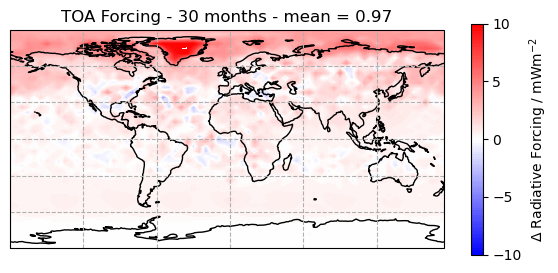

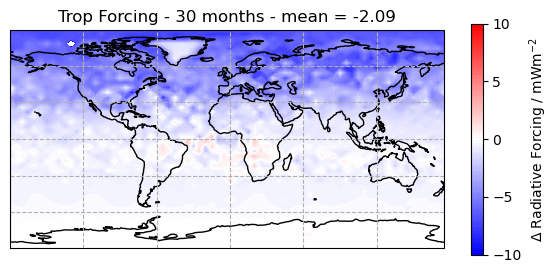

In [87]:
months_passed = int(mth) + 12*(int(year)-2020)
met = xr.open_dataset(f'/home/ucfacb0/Scratch/StateMet/4x5/{year}/GEOSChem.StateMet.{year}{mth}01_0000z.nc4')
try:
    wr  = xr.open_dataset(filepath+rocketsSim+f'/GEOSChem.RRTMG.{year}{mth}01_0000z.nc4') 
except:
    wr  = xr.open_dataset(filepath+rocketsSim+f'/before_atlas_fix/GEOSChem.RRTMG.{year}{mth}01_0000z.nc4') 
nr  = xr.open_dataset(filepath+norocketsSim+f'/GEOSChem.RRTMG.{year}{mth}01_0000z.nc4' )
time, lon, lat = nr.variables['time'][:], nr.variables['lon'][:], nr.variables['lat'][:]

def print_contour(diff_mWm2,spec,net):
    fig = plt.figure(figsize=[7,3])
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()
    ax.gridlines(linestyle='--')
    cmap_extent = 10
    cf = ax.contourf( lon, lat, diff_mWm2, cmap = 'bwr', levels=np.linspace( -cmap_extent, cmap_extent,100))
    cbar = fig.colorbar(cf, ax=ax, ticks = np.linspace(-cmap_extent, cmap_extent,5),label="$\Delta$ Radiative Forcing / mWm$^{-2}$")
    #ax.set_title(f"Net All-sky {wave} RF at {loc} - {months_passed} months - {spec} ($\mu$ = {net:.2f})")
    ax.set_title(f"{loc} Forcing - {months_passed} months - mean = {net:.2f}")

data_stack = np.zeros((len(species),len(locs)))
net = np.zeros((len(locs)))
for loc_count, loc in enumerate(locs):
    
    if wave == "Total":
        labs,labl = f'RadAllSkySW{loc}_BASE', f'RadAllSkyLW{loc}_BASE'
        radnr = nr[labs].isel(time=0) + nr[labl].isel(time=0)
        radwr = wr[labs].isel(time=0) + wr[labl].isel(time=0)    
    else:
        lab = f'RadAllSky{wave}{loc}_BASE'
        radnr  = nr[lab].isel(time=0)
        radwr  = wr[lab].isel(time=0)       
    
    diff_mWm2 = 1000*(radwr - radnr)
    net[loc_count] = diff_mWm2.mean().values
    print(np.max(diff_mWm2.mean().values))
    print_contour(diff_mWm2,"BASE",net[loc_count])
     
    for count,spec in enumerate(species):
        
        if wave == "Total":
            labs,labl = f'RadAllSkySW{loc}_{spec}', f'RadAllSkyLW{loc}_{spec}'
            #radnr_spec = (nr[f'RadAllSkySW{loc}_BASE'].isel(time=0) - nr[labs].isel(time=0)) + (nr[f'RadAllSkyLW{loc}_BASE'].isel(time=0) - nr[labl].isel(time=0))
            #radwr_spec = (wr[f'RadAllSkySW{loc}_BASE'].isel(time=0) - wr[labs].isel(time=0)) + (wr[f'RadAllSkyLW{loc}_BASE'].isel(time=0) - wr[labl].isel(time=0))
            radnr_spec = nr[labs].isel(time=0) + nr[labl].isel(time=0)
            radwr_spec = wr[labs].isel(time=0) + wr[labl].isel(time=0)
        else:   
            lab = f'RadAllSky{wave}{loc}_{spec}'    
            #radnr_spec = radnr - nr[lab].isel(time=0)
            #radwr_spec = radwr - wr[lab].isel(time=0)
            radnr_spec = nr[lab].isel(time=0)
            radwr_spec = wr[lab].isel(time=0)
            
        rad_diff[loc_count,count] = np.nanmean(1000*(radwr_spec - radnr_spec))
        diff_mWm2 = 1000*(radwr_spec - radnr_spec)
        
    data = rad_diff[loc_count,:]
    data_shape = np.shape(data)

    # Take negative and positive data apart and cumulate
    def get_cumulated_array(data, **kwargs):
        cum = data.clip(**kwargs)
        cum = np.cumsum(cum, axis=0)
        d = np.zeros(np.shape(data))
        d[1:] = cum[:-1]
        return d  

    cumulated_data = get_cumulated_array(data, min=0)
    cumulated_data_neg = get_cumulated_array(data, max=0)

    # Re-merge negative and positive data.
    row_mask = (data<0)
    cumulated_data[row_mask] = cumulated_data_neg[row_mask]
    data_stack[:,loc_count] = cumulated_data


[[ 0.00930771  3.03480077 -1.01120603 -0.02788546 -0.41341433]
 [-0.0076912  -2.44481587  0.37025046  0.01387779 -0.05687118]]


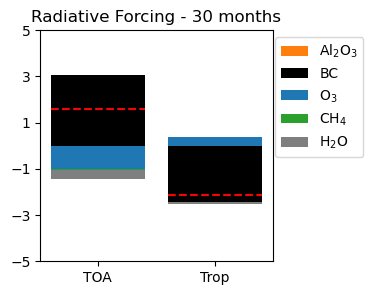

In [88]:
species_list_label = ["Al$_{2}$O$_{3}$","BC","O$_{3}$","CH$_{4}$","H$_{2}$O"]    
width=0.8
color_list = ["tab:orange","k","tab:blue","tab:green","tab:gray"]   
fig = plt.figure(figsize=[3,3])
ax = plt.subplot(111)
for i in np.arange(0, data_shape[0]):
    ax.bar(locs[0], rad_diff[0,i], width=-width, bottom=data_stack[i,0],label=species_list_label[i],color=color_list[i],alpha = 1)
for i in np.arange(0, data_shape[0]):
    ax.bar(locs[1], rad_diff[1,i], width=width, bottom=data_stack[i,1],color=color_list[i],alpha = 1)
ymin = -5
ymax = 5
ax.set_ylim(ymin,ymax)
ax.set_yticks(ticks=np.linspace(ymin,ymax,6))
ax.set_title(f"Radiative Forcing - {months_passed} months")
ax.legend(loc='upper center', bbox_to_anchor=(1.2, 1), ncol=1)
ax.plot([-width/2,width/2],[np.sum(rad_diff[0]),np.sum(rad_diff[0])],ls='--', c='r')
ax.plot([width*0.75,width*1.75],[np.sum(rad_diff[1]),np.sum(rad_diff[1])],ls='--', c='r')
print(rad_diff)

In [89]:
wr.close()
nr.close()
met.close()

In [90]:
def print_rrtmg(output):

    wr  = xr.open_dataset("/home/ucfacb0/rundirs/Rockets/gc_4x5_47L_merra2_fullchem_main/OutputDir/Rockets/GEOSChem.RRTMG.20210601_0000z.nc4")
    fig = plt.figure(figsize=[8,4])
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()
    ax.gridlines(linestyle='--')
    total = wr[f"RadAllSkyLWTOA_{output}"].isel(time=0) + wr[f"RadAllSkySWTOA_{output}"].isel(time=0)
    max_range = np.ceil(np.abs(np.max(total)))
    total.plot(ax=ax, cmap="bwr",vmin=-max_range,vmax=max_range)
    ax.set_title(f"Rocket Sim All-sky Total TOA RF - {output}")
    wr.close()
    
spec_names = ["O3","ME","SU","NI","AM","BC","OA","SS","DU","PM","ST"]
interact(print_rrtmg,
        output=Dropdown(options=spec_names, continuous_update=True),
        );


interactive(children=(Dropdown(description='output', options=('O3', 'ME', 'SU', 'NI', 'AM', 'BC', 'OA', 'SS', …

In [91]:
wr  = xr.open_dataset("/home/ucfacb0/rundirs/Rockets/gc_4x5_47L_merra2_fullchem_main/OutputDir/Rockets/HEMCO_diagnostics.202201010000.nc")
print()
al2o3 = np.sum(wr["EmisAl2O3_SMF_Rocket"]).values
dst1  = np.sum(wr["EmisAl2O3_DST1_Rocket"]).values
dst2  = np.sum(wr["EmisAl2O3_DST2_Rocket"]).values
dst3  = np.sum(wr["EmisAl2O3_DST3_Rocket"]).values
dst4  = np.sum(wr["EmisAl2O3_DST4_Rocket"]).values
print(f'DST1 = {dst1:.2f}  kg\nDST2 = {dst2:.2f} kg\nDST3 = {dst3:.2f} kg\nDST4 = {dst4:.2f} kg')
print(dst1/np.sum(dst1+dst2+dst3+dst4))
print(dst2/np.sum(dst1+dst2+dst3+dst4))
print(dst3/np.sum(dst1+dst2+dst3+dst4))
print(dst4/np.sum(dst1+dst2+dst3+dst4))
print(al2o3/np.sum(dst1+dst2+dst3+dst4))
total_mass = 200*0.4
print(total_mass,np.sum(dst1+dst2+dst3+dst4))

DST1 = 3069.53  kg
DST2 = 11779.33 kg
DST3 = 11779.33 kg
DST4 = 11779.33 kg
0.079920076
0.30669332
0.30669332
0.30669332
0.079920076
80.0 38407.52


In [92]:
wr.close()